# 01 — Data Setup

This notebook walks through every step needed to go from a blank slate to
a clean set of training-ready parquets:

1. Load your `config.yaml` and display a summary.
2. Draw your bounding box on an interactive map and confirm the ASOS stations inside it.
3. Download ASOS observations and resample them to 1-hourly parquets.
4. Download HRRR forecasts for every forecast hour in your config.
5. Quality-check the data: availability heatmap (station × date, % missing).
6. Build the station-cluster lookup parquet that the model needs.

**Run each cell in order.** The first code cell installs packages from `requirements.txt`
at the repo root (next to `app/`). Heavy download steps (HRRR, ASOS) can take
minutes to hours depending on your date range and internet connection.
All outputs are written to `./output/` (relative to `app/`) and every
step is resume-friendly — re-running a cell skips already-downloaded files.

In [ ]:
# Install third-party packages listed in ``requirements.txt`` (repo root next to ``app/``).
from pathlib import Path
import subprocess
import sys

_cwd = Path.cwd().resolve()
if (_cwd / "src").is_dir() and (_cwd / "app").is_dir():
    _repo = _cwd
elif (_cwd.parent / "src").is_dir() and (_cwd.parent / "app").is_dir():
    _repo = _cwd.parent
elif (_cwd.parent.parent / "src").is_dir() and (_cwd.parent.parent / "app").is_dir():
    _repo = _cwd.parent.parent
else:
    raise RuntimeError(
        f"Cannot infer repo root from cwd={_cwd}. Run from app/ or app/notebooks/."
    )

_req = _repo / "requirements.txt"
if not _req.is_file():
    raise FileNotFoundError(f"Missing {_req}")
subprocess.check_call([sys.executable, "-m", "pip", "install", "-r", str(_req)])
print("Installed packages from", _req)

In [13]:
import sys, os
from pathlib import Path

# Resolve repo root whether cwd is ``app/`` or ``app/notebooks/`` (``../..`` breaks
# after ``chdir(app)`` on a second run).
_cwd = Path.cwd().resolve()
if (_cwd / "src").is_dir() and (_cwd / "app").is_dir():
    REPO_ROOT = _cwd
elif (_cwd.parent / "src").is_dir() and (_cwd.parent / "app").is_dir():
    REPO_ROOT = _cwd.parent
elif (_cwd.parent.parent / "src").is_dir() and (_cwd.parent.parent / "app").is_dir():
    REPO_ROOT = _cwd.parent.parent
else:
    raise RuntimeError(
        f"Cannot infer repo root from cwd={_cwd}. Run from app/ or app/notebooks/."
    )
APP_ROOT = REPO_ROOT / "app"
SRC_ROOT = REPO_ROOT / "src"

# Prepend so final sys.path order is src → repo → app (see ``02_train`` first cell).
for p in (str(APP_ROOT), str(REPO_ROOT), str(SRC_ROOT)):
    if p not in sys.path:
        sys.path.insert(0, p)

os.chdir(APP_ROOT)  # resolve relative paths in config.yaml from app/
print("Working directory:", os.getcwd())
print("REPO_ROOT:", REPO_ROOT)
# This cell does not fetch station obs — load ``cfg`` next, then run Step 2 for IEM ASOS
# (unless ``data.mesonet_local_dir`` already contains ``mesonet_1H_obs_*.parquet``).

Working directory: /Users/aevans/Documents/forecast_error


In [14]:
from app.utils.config_loader import load_config

cfg = load_config()   # reads app/config.yaml
cfg.make_output_dirs()

print("=== Configuration ===")
print(f"  Bounding box  : lat=[{cfg.bbox.lat_min}, {cfg.bbox.lat_max}]"
      f"  lon=[{cfg.bbox.lon_min}, {cfg.bbox.lon_max}]")
print(f"  Mesonet source: {cfg.data.mesonet_source}")
print(f"  Forecast hours: {cfg.data.forecast_hours}")
print(f"  Met variables : {cfg.data.metvars}")
print(f"  Model type    : {cfg.model}")
print(f"  Training      : {cfg.training.start_date} → {cfg.training.end_date}")
print(f"  Train/Val/Test: {cfg.training.train_frac:.0%} / "
      f"{cfg.training.val_frac:.0%} / {cfg.training.test_frac:.0%}")
print(f"  Device id     : {cfg.training.device_id}")

=== Configuration ===
  Bounding box  : lat=[40.0, 41.5]  lon=[-80.0, -78.5]
  Mesonet source: asos
  Forecast hours: [1]
  Met variables : ['t2m', 'u_total', 'tp']
  Model type    : lstm
  Training      : 2026-01-01 → 2026-01-03
  Train/Val/Test: 70% / 15% / 15%
  Device id     : 0


## Step 1 — Visualise the bounding box and ASOS stations

In [15]:
import base64
import folium
from pathlib import Path
from IPython.display import IFrame, display
from app.utils.bbox_filter import bbox_corners
from app.data.fetch_asos import get_asos_stations_in_bbox

# Centre the map on the bbox midpoint
centre_lat = (cfg.bbox.lat_min + cfg.bbox.lat_max) / 2
centre_lon = (cfg.bbox.lon_min + cfg.bbox.lon_max) / 2
m = folium.Map(location=[centre_lat, centre_lon], zoom_start=7, tiles="CartoDB positron")

# Draw the bbox polygon
corners = bbox_corners(cfg.bbox)
folium.Polygon(
    locations=corners,
    color="#e63946",
    weight=2,
    fill=True,
    fill_opacity=0.08,
    tooltip="Bounding box",
).add_to(m)

# Query ASOS station inventory and add markers
print("Fetching ASOS station inventory …")
station_meta = get_asos_stations_in_bbox(
    cfg.bbox.lat_min, cfg.bbox.lat_max, cfg.bbox.lon_min, cfg.bbox.lon_max
)
print(f"  {len(station_meta)} stations found inside the bbox.")

for _, row in station_meta.iterrows():
    folium.CircleMarker(
        location=[row.lat, row.lon],
        radius=5,
        color="#457b9d",
        fill=True,
        fill_opacity=0.8,
        tooltip=f"{row.station} — {row.get('name', '')}",
    ).add_to(m)


_map_html = Path(cfg.output.results_dir) / "bbox_station_map.html"
m.save(str(_map_html))
print(f"Also saved to {_map_html} — open in a browser if the inline map is empty or huge.")

_b64 = base64.b64encode(m.get_root().render().encode("utf-8")).decode("ascii")
display(IFrame(src=f"data:text/html;charset=utf-8;base64,{_b64}", width="100%", height=520))

Fetching ASOS station inventory …
  10 stations found inside the bbox.
Also saved to /Users/aevans/Documents/forecast_error/inference_ai2es_forecast_err/app/output/results/bbox_station_map.html — open in a browser if the inline map is empty or huge.


In [16]:
# Preview the station metadata table
station_meta.head(10)

,station,name,lat,lon,elev,network
0,2G9,Somerset,40.0389,-79.0150,679.99380,PA_ASOS
1,AGC,PITTSBURGH/ALLEGHEN,40.3547,-79.9217,382.00000,PA_ASOS
2,BTP,BUTLER CO. (AWOS),40.7769,-79.9497,380.00000,PA_ASOS
3,DUJ,DU BOIS (AWOS),41.1800,-78.9000,554.00000,PA_ASOS
4,FKL,FRANKLIN(AWOS),41.3779,-79.8604,469.00000,PA_ASOS
5,HMZ,Bedford,40.0853,-78.5122,350.62582,PA_ASOS
6,IDI,INDIANA/STEWART FLD,40.6322,-79.1055,429.00000,PA_ASOS
7,JST,JOHNSTOWN/CAMBRIA,40.3161,-78.8339,696.00000,PA_ASOS
8,LBE,LATROBE/WESTMORLAND,40.2759,-79.4048,361.00000,PA_ASOS
9,OYM,St Marys,41.4125,-78.5026,579.19050,PA_ASOS


## Step 2 — Download ASOS observations

This step runs **after** `cfg = load_config()` above. The first notebook cell only
sets Python paths and working directory; it never downloads data.

With default `mesonet_source: asos` and `mesonet_local_dir: null`, this cell calls
the **IEM REST API** in 30-day chunks. If `mesonet_local_dir` points at a folder that
already has `mesonet_1H_obs_*.parquet` files (mounted mesonet), that branch is used
instead and IEM is skipped.

For a 2-year window with ~60 stations IEM typically takes 5–15 minutes.
Already-downloaded years are skipped automatically.

In [17]:
import importlib
from pathlib import Path

import app.data.fetch_asos as _fetch_asos_mod

importlib.reload(_fetch_asos_mod)
from app.data.fetch_asos import fetch_asos_for_bbox
from app.utils.mesonet_setup import (
    ensure_mesonet_parquets_staged,
    load_station_meta_for_local_mesonet,
    use_local_mesonet,
)

_src = Path(_fetch_asos_mod.__file__).resolve()
assert "_write_mesonet_parquet" in _src.read_text(
    encoding="utf-8"
), (
    f"Stale fetch_asos.py at {_src} — restart the kernel, pull the latest repo, "
    "and run the first path-setup cell again."
)
print(f"ASOS writer: {_src}")

lookups_dir = Path(cfg.output.models_dir) / "lookups"
lookups_dir.mkdir(parents=True, exist_ok=True)
meta_out = lookups_dir / "station_meta.csv"

_use_local = use_local_mesonet(cfg)
print(
    f"Observation branch: {'mounted/local parquets (IEM skipped)' if _use_local else 'IEM ASOS download'} | "
    f"mesonet_source={cfg.data.mesonet_source!r}, mesonet_local_dir={cfg.data.mesonet_local_dir!r}"
)

if _use_local:
    ensure_mesonet_parquets_staged(cfg)
    station_meta = load_station_meta_for_local_mesonet(cfg)
    station_meta.to_csv(meta_out, index=False)
    print(
        f"Using local / mounted mesonet (skipped IEM ASOS download). "
        f"Wrote {len(station_meta)} stations → {meta_out}"
    )
else:
    station_meta = fetch_asos_for_bbox(
        cfg,
        cfg.training.start_date,
        cfg.training.end_date,
        show_progress=True,
    )
    print("\nASOS download complete.")

ASOS writer: /Users/aevans/Documents/forecast_error/inference_ai2es_forecast_err/app/data/fetch_asos.py
Searching ASOS stations in lat=[40.0, 41.5] lon=[-80.0, -78.5] …
  Found 10 ASOS stations.
  Station metadata saved to /Users/aevans/Documents/forecast_error/inference_ai2es_forecast_err/app/output/models/lookups/station_meta.csv
  [fetch] 2026-01-01 → 2026-01-03 (10 stations) … 725 rows.
  Written: /Users/aevans/Documents/forecast_error/inference_ai2es_forecast_err/app/output/parquets/mesonet/mesonet_1H_obs_2026.parquet (725 rows for 2026)

ASOS download complete.


## Step 3 — Download HRRR forecasts

> **Warning**: Downloading years of raw HRRR grib2 data is disk- and
> time-intensive.  Each grib2 file is ~50–200 MB; Herbie caches those under
> `data.hrrr_raw_dir`.  Only the variables the pipeline needs are extracted
> before writing the cleaned parquets under `data.parquets_dir`.
>
> If you already have **pre-cleaned** HRRR parquets (same filenames as this
> step produces), copy or symlink them into
> `{parquets_dir}/hrrr_data/fh{N}/` for each forecast hour `N`, or point
> `parquets_dir` at a tree that already matches that layout — then skip this
> cell.  (`hrrr_raw_dir` is only for raw grib2 cache; do not point it at
> finished parquets.)

In [18]:
from app.data.fetch_hrrr import fetch_and_stage

fetch_and_stage(
    cfg,
    cfg.training.start_date,
    cfg.training.end_date,
    station_lookup=station_meta,
    show_progress=True,
)
print("HRRR staging complete.")

  [fetch] fh=01 2026-01 …

/Users/aevans/miniforge3/lib/python3.12/site-packages/cfgrib/xarray_store.py:51: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  o = xr.merge([o, ds], **kwargs)
/Users/aevans/miniforge3/lib/python3.12/site-packages/cfgrib/xarray_store.py:51: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  o = xr.merge([o, ds], **kwargs)
/Users/aevans/mini

 720 rows written.
HRRR staging complete.


## Step 4 — Data availability quality check

This heatmap shows the fraction of hourly observations that are non-missing
for each station and calendar day.  Aim for ≥ 80 % coverage before training.

Matplotlib is building the font cache; this may take a moment.


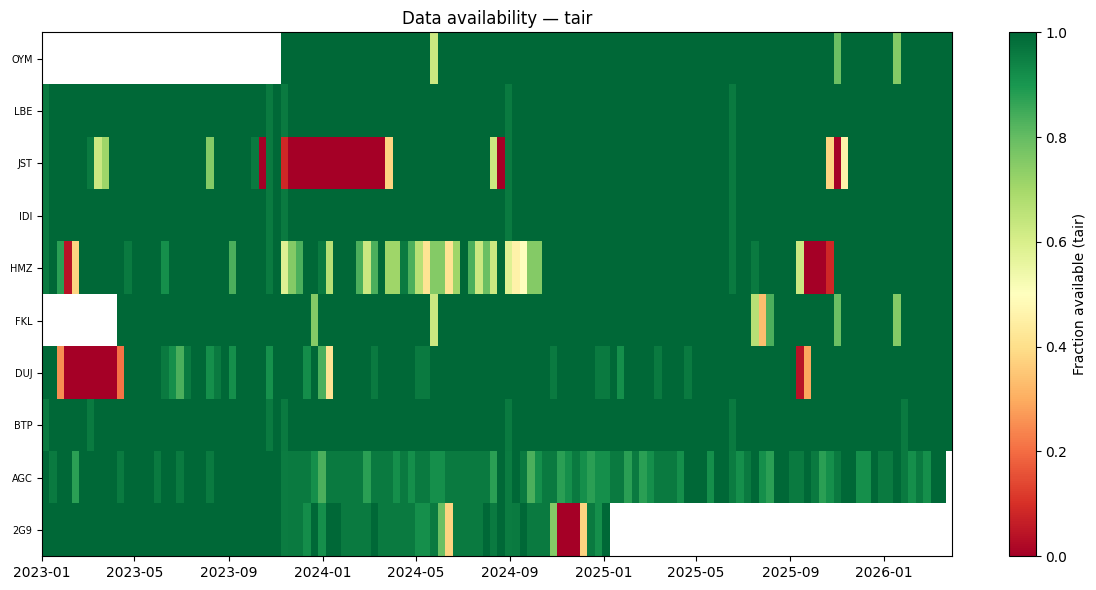


Median availability: 100.0%


In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path

mesonet_dir = Path(cfg.data.parquets_dir) / "mesonet"
all_obs = []
for pq in sorted(mesonet_dir.glob("mesonet_1H_obs_*.parquet")):
    df = pd.read_parquet(pq)
    if df.index.nlevels > 1:
        df = df.reset_index()
    all_obs.append(df)

if not all_obs:
    print("No mesonet parquets found — run the ASOS download step first.")
else:
    obs = pd.concat(all_obs, ignore_index=True)
    obs["time_1H"] = pd.to_datetime(obs["time_1H"], utc=True, errors="coerce")
    obs["date"] = obs["time_1H"].dt.date

    # Fraction of non-missing tair observations per (station, date)
    avail = (
        obs.groupby(["station", "date"])["tair"]
        .apply(lambda s: (s != -999).mean())
        .unstack("station")
    )
    avail.index = pd.to_datetime(avail.index)

    fig, ax = plt.subplots(figsize=(max(12, len(avail.columns) * 0.3), 6))
    im = ax.imshow(
        avail.T.values,
        aspect="auto",
        vmin=0, vmax=1,
        cmap="RdYlGn",
        extent=[
            mdates.date2num(avail.index[0].to_pydatetime()),
            mdates.date2num(avail.index[-1].to_pydatetime()),
            -0.5, len(avail.columns) - 0.5,
        ],
    )
    ax.xaxis_date()
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
    ax.set_yticks(range(len(avail.columns)))
    ax.set_yticklabels(avail.columns, fontsize=7)
    plt.colorbar(im, ax=ax, label="Fraction available (tair)")
    ax.set_title("Data availability — tair")
    plt.tight_layout()
    plt.savefig(Path(cfg.output.results_dir) / "data_availability.png", dpi=150)
    plt.show()
    print(f"\nMedian availability: {avail.median().median():.1%}")

## Step 5 — Build station clusters

The model takes **four stations** as input: the target station plus its three
nearest neighbours.  This step computes and caches that lookup table.

In [22]:
from app.data.build_station_clusters import build_clusters

lookup_df = build_clusters(cfg, station_meta=station_meta, show_progress=True)
print(f"\nLookup table has {len(lookup_df)} entries.")
lookup_df.head()

  Computing 4-nearest-neighbour clusters for 10 stations … done.  Written to /Users/aevans/Documents/forecast_error/inference_ai2es_forecast_err/app/output/models/lookups/triangulate_stations.parquet

Lookup table has 10 entries.


,station,closest_stations
0,2G9,"['2G9', 'JST', 'LBE', 'HMZ']"
1,AGC,"['AGC', 'LBE', 'BTP', 'IDI']"
2,BTP,"['BTP', 'AGC', 'FKL', 'LBE']"
3,DUJ,"['DUJ', 'OYM', 'IDI', 'FKL']"
4,FKL,"['FKL', 'BTP', 'DUJ', 'IDI']"


## All done!

Your output directory should now contain:

```
output/
├── parquets/
│   ├── mesonet/mesonet_1H_obs_{YYYY}.parquet
│   └── hrrr_data/fh{N}/HRRR_{YYYY}_{MM}_...parquet
├── models/lookups/
│   ├── station_meta.csv
│   └── triangulate_stations.parquet
└── results/data_availability.png
```

Open **`02_train.ipynb`** to train the model.